# Pipeline de ciência de dados — atrasos de voos (EUA)

**Objetivos:** explorar o dataset de voos domésticos (2015), tratar dados ausentes, treinar modelos **supervisionados** (classificação de atraso na chegada e regressão do tempo de atraso) e **não supervisionados** (PCA e clusterização por companhia), com interpretação crítica.

**Nota metodológica:** os preditores usados correspondem apenas a informação **disponível antes da partida** (sem `DEPARTURE_DELAY`, tempos reais de voo, etc.), para evitar *data leakage*.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from config import AIRLINES_CSV, DEFAULT_SAMPLE_SIZE, FLIGHTS_CSV, RANDOM_SEED
from src.features import build_model_frame, X_y_classification
from src.load_data import load_airlines, load_flights_sample
from src.preprocess import make_column_transformer

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(RANDOM_SEED)

SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
print("ROOT:", ROOT)
print("Amostra:", SAMPLE_SIZE)

ROOT: /Users/cultivi_it/Documents/TechChallenge
Amostra: 500000


In [2]:
airlines = load_airlines(AIRLINES_CSV)
flights_raw = load_flights_sample(FLIGHTS_CSV, n=SAMPLE_SIZE, seed=RANDOM_SEED)
flights_raw["AIRLINE"] = flights_raw["AIRLINE"].astype(str)

flights_eda = flights_raw.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left",
    suffixes=("", "_full"),
)
flights_eda["AIRLINE_NAME"] = flights_eda["AIRLINE_full"].fillna(flights_eda["AIRLINE"])

print(flights_raw.shape)
flights_raw.head()

(500000, 31)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,12,13,7,VX,34,N842VA,SFO,JFK,2315,...,812.0,22.0,0,0,NaN,0.0,0.0,0.0,22.0,0.0
1,2015,6,3,3,WN,772,N410WN,STL,EWR,855,...,1220.0,0.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,6,30,2,MQ,3205,N609MQ,DFW,HOU,1350,...,1459.0,-5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,4,5,7,AS,342,N506AS,SEA,OAK,600,...,804.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,24,6,DL,1489,N922AT,ATL,IAH,1342,...,1509.0,9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Exploração dos dados (EDA)

### 1.1 Estatísticas descritivas e dados ausentes

Colunas de atraso atribuível (`AIR_SYSTEM_DELAY`, etc.) só têm valores quando há decomposição do atraso — não são usadas como preditores (evitam *leakage*). `TAIL_NUMBER` ausente não entra no modelo.

In [3]:
desc_num = flights_raw.select_dtypes(include=[np.number]).describe().T
desc_num.round(2)

,count,mean,std,min,25%,50%,75%,max
YEAR,500000.0,2015.00,0.00,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,500000.0,6.52,3.41,1.0,4.0,7.0,9.0,12.0
DAY,500000.0,15.69,8.78,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,500000.0,3.92,1.99,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,500000.0,2171.04,1755.09,1.0,730.0,1689.0,3227.0,7438.0
SCHEDULED_DEPARTURE,500000.0,1329.82,484.07,1.0,916.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,492525.0,1335.36,496.55,1.0,921.0,1330.0,1740.0,2400.0
DEPARTURE_DELAY,492525.0,9.32,36.82,-48.0,-5.0,-2.0,7.0,1557.0
TAXI_OUT,492255.0,16.07,8.92,1.0,11.0,14.0,19.0,179.0
WHEELS_OFF,492255.0,1357.23,498.20,1.0,935.0,1343.0,1754.0,2400.0


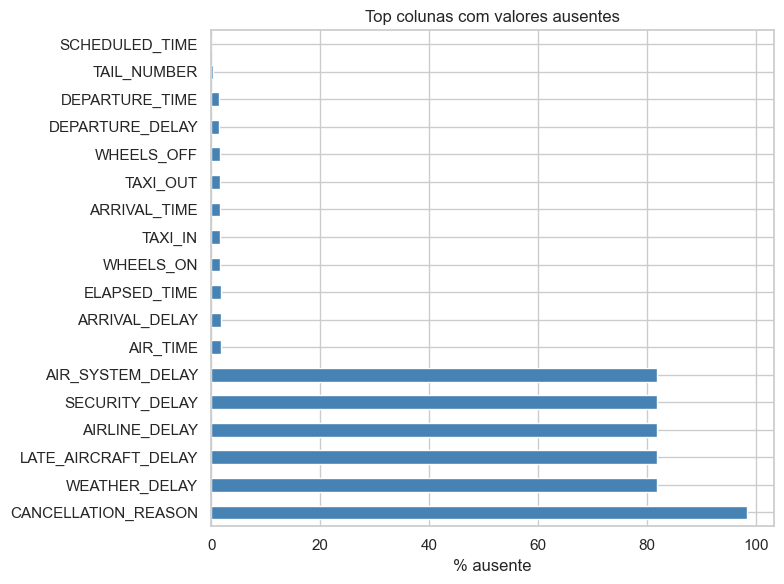

Colunas com >0% ausente (amostra):
 CANCELLATION_REASON    98.4382
WEATHER_DELAY          81.8090
LATE_AIRCRAFT_DELAY    81.8090
AIRLINE_DELAY          81.8090
SECURITY_DELAY         81.8090
AIR_SYSTEM_DELAY       81.8090
AIR_TIME                1.8276
ARRIVAL_DELAY           1.8276
ELAPSED_TIME            1.8276
WHEELS_ON               1.6068
TAXI_IN                 1.6068
ARRIVAL_TIME            1.6068
TAXI_OUT                1.5490
WHEELS_OFF              1.5490
DEPARTURE_DELAY         1.4950


In [4]:
missing_pct = (flights_raw.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
ax = missing_pct.head(20).plot(kind="barh", color="steelblue", figsize=(8, 6))
ax.set_xlabel("% ausente")
ax.set_title("Top colunas com valores ausentes")
plt.tight_layout()
plt.show()
print("Colunas com >0% ausente (amostra):\n", missing_pct.head(15).to_string())

### 1.2 Visualizações

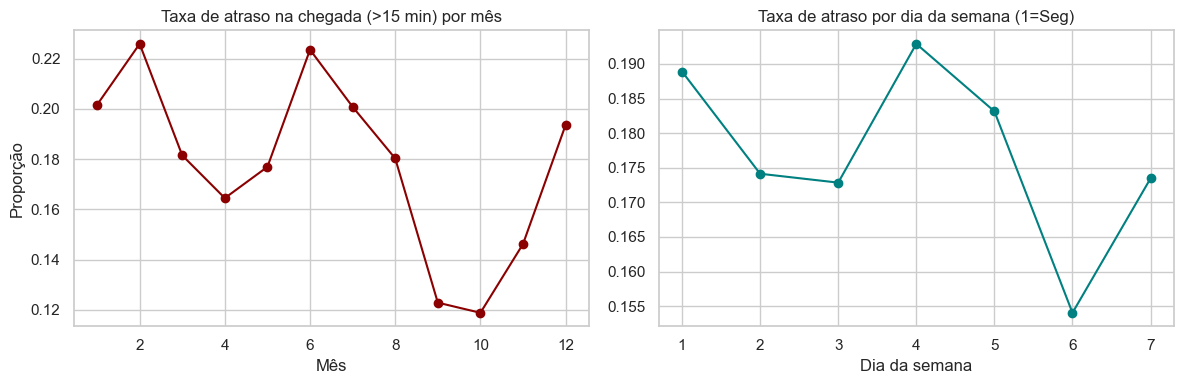

In [5]:
oper = flights_raw[flights_raw["CANCELLED"] == 0].copy()
oper["DELAYED_15"] = (oper["ARRIVAL_DELAY"] > 15).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
oper.groupby("MONTH")["DELAYED_15"].mean().plot(ax=axes[0], marker="o", color="darkred")
axes[0].set_title("Taxa de atraso na chegada (>15 min) por mês")
axes[0].set_ylabel("Proporção")
axes[0].set_xlabel("Mês")
oper.groupby("DAY_OF_WEEK")["DELAYED_15"].mean().plot(ax=axes[1], marker="o", color="teal")
axes[1].set_title("Taxa de atraso por dia da semana (1=Seg)")
axes[1].set_xlabel("Dia da semana")
plt.tight_layout()
plt.show()

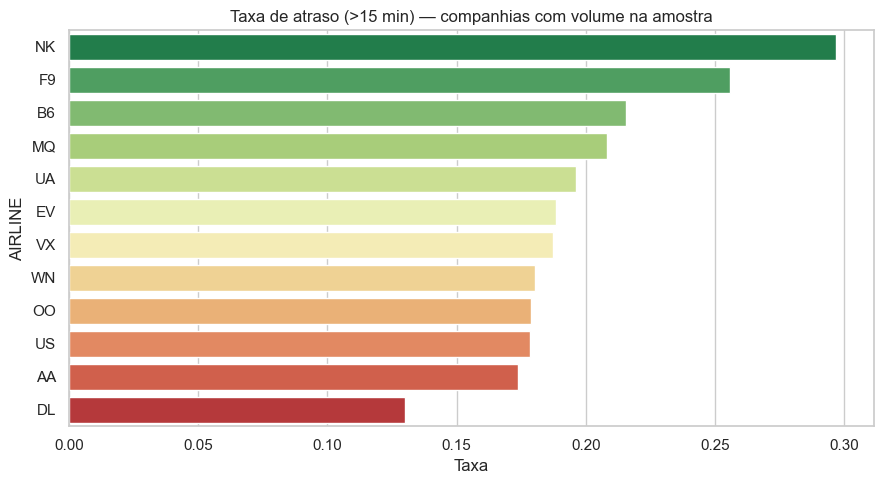

In [6]:
top_air = (
    oper.groupby("AIRLINE", as_index=False)
    .agg(delay_rate=("DELAYED_15", "mean"), n=("DELAYED_15", "size"))
    .query("n >= 500")
    .sort_values("delay_rate", ascending=False)
    .head(12)
)
top_air = top_air.merge(
    airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"}),
    left_on="AIRLINE",
    right_on="IATA_CODE",
    how="left",
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_air, y="AIRLINE", x="delay_rate", hue="AIRLINE", palette="RdYlGn_r", ax=ax, legend=False)
ax.set_title("Taxa de atraso (>15 min) — companhias com volume na amostra")
ax.set_xlabel("Taxa")
plt.tight_layout()
plt.show()

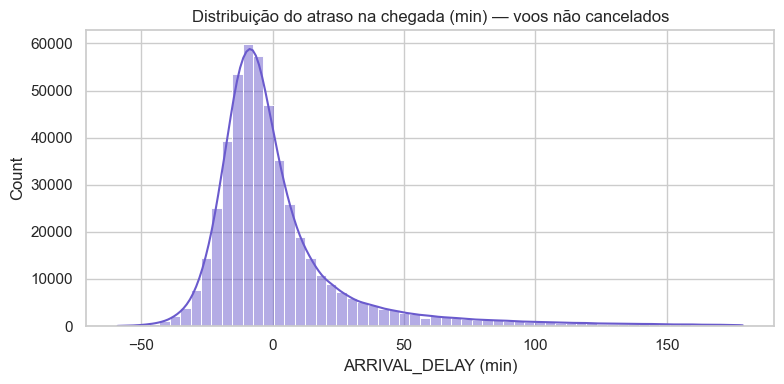

In [7]:
sample_delay = oper["ARRIVAL_DELAY"].dropna()
sample_delay = sample_delay[(sample_delay > -60) & (sample_delay < 180)]
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sample_delay, bins=60, kde=True, ax=ax, color="slateblue")
ax.set_title("Distribuição do atraso na chegada (min) — voos não cancelados")
ax.set_xlabel("ARRIVAL_DELAY (min)")
plt.tight_layout()
plt.show()

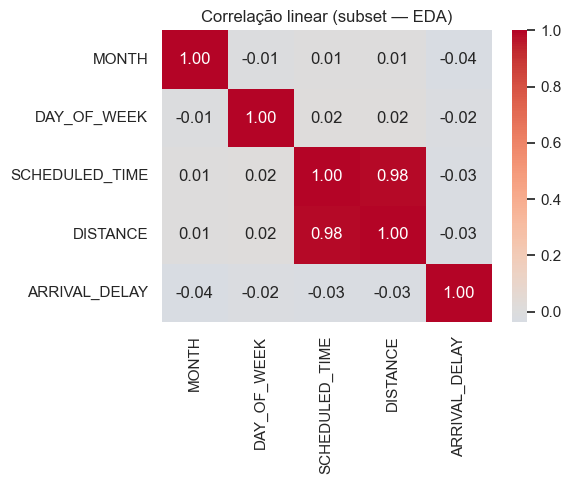

In [8]:
corr_cols = ["MONTH", "DAY_OF_WEEK", "SCHEDULED_TIME", "DISTANCE", "ARRIVAL_DELAY"]
c = oper[corr_cols].dropna().corr()
plt.figure(figsize=(6, 5))
sns.heatmap(c, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação linear (subset — EDA)")
plt.tight_layout()
plt.show()

### 1.3 Tratamento de ausentes (modelagem)

- **Cancelados / desviados:** excluídos.
- **Numéricas:** imputação pela **mediana** no pré-processamento.
- **Categóricas:** `OneHotEncoder(handle_unknown='ignore')`.

## 2. Modelagem supervisionada

**Classificação:** `ARRIVAL_DELAY > 15` min. **Regressão:** `ARRIVAL_DELAY` (min). **Split:** 80/20, estratificado na classe.

In [9]:
model_df = build_model_frame(flights_raw)
X_c, y_c = X_y_classification(model_df)
y_r_series = model_df.loc[X_c.index, "ARRIVAL_DELAY_MIN"]

X_train_c, X_test_c, y_train_c, y_test_c, y_train_r, y_test_r = train_test_split(
    X_c, y_c, y_r_series, test_size=0.2, random_state=RANDOM_SEED, stratify=y_c
)
X_train_r, X_test_r = X_train_c, X_test_c

print(model_df.shape, "linhas após filtros")
print("Proporção atrasados:", round(float(np.mean(y_c)), 3))

(490862, 35) linhas após filtros
Proporção atrasados: 0.178


### 2.1 Classificação — Regressão logística vs Random Forest

,modelo,ROC-AUC,F1,Accuracy
0,Regressão logística,0.639165,0.349880,0.595530
1,Random Forest,0.670263,0.370832,0.619101


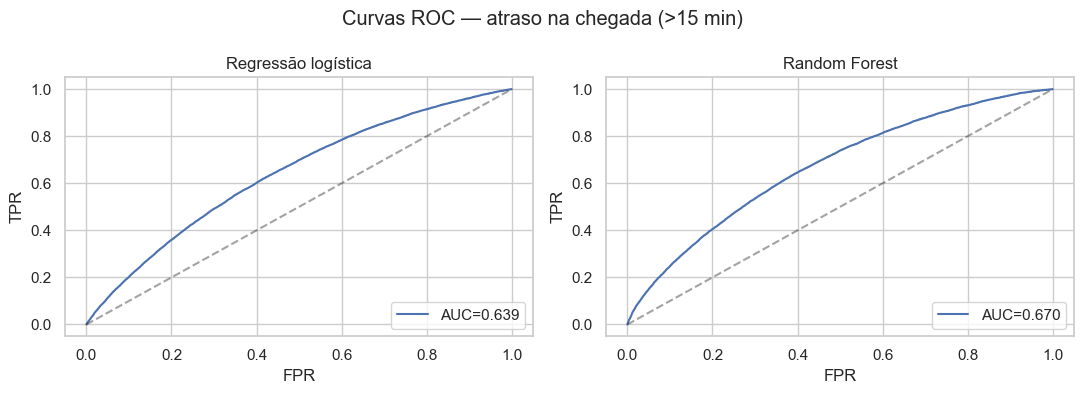

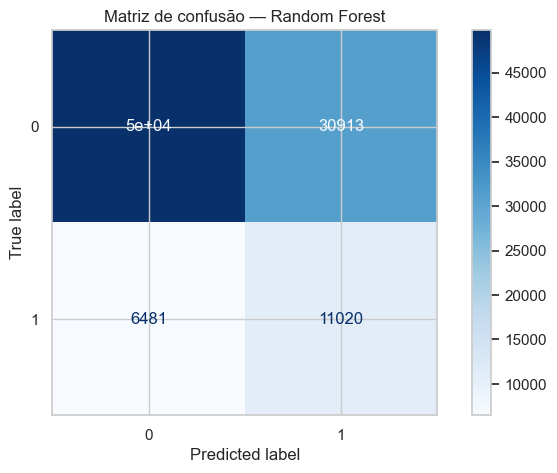

              precision    recall  f1-score   support

           0      0.885     0.617     0.727     80672
           1      0.263     0.630     0.371     17501

    accuracy                          0.619     98173
   macro avg      0.574     0.623     0.549     98173
weighted avg      0.774     0.619     0.663     98173



In [10]:
prep = make_column_transformer(max_categories=40)

clf_lr = Pipeline(
    [
        ("prep", prep),
        (
            "model",
            LogisticRegression(
                max_iter=2500,
                solver="saga",
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)
clf_rf = Pipeline(
    [
        ("prep", make_column_transformer(max_categories=40)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=120,
                max_depth=16,
                min_samples_leaf=50,
                class_weight="balanced_subsample",
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

clf_lr.fit(X_train_c, y_train_c)
clf_rf.fit(X_train_c, y_train_c)


def eval_clf(name, pipe):
    proba = pipe.predict_proba(X_test_c)[:, 1]
    pred = pipe.predict(X_test_c)
    return {
        "modelo": name,
        "ROC-AUC": roc_auc_score(y_test_c, proba),
        "F1": f1_score(y_test_c, pred),
        "Accuracy": accuracy_score(y_test_c, pred),
    }


metrics_clf = pd.DataFrame([eval_clf("Regressão logística", clf_lr), eval_clf("Random Forest", clf_rf)])
display(metrics_clf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pipe) in zip(
    axes,
    [("Regressão logística", clf_lr), ("Random Forest", clf_rf)],
):
    proba = pipe.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    ax.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test_c, proba):.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(name)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right")
plt.suptitle("Curvas ROC — atraso na chegada (>15 min)")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_estimator(clf_rf, X_test_c, y_test_c, cmap="Blues")
plt.title("Matriz de confusão — Random Forest")
plt.show()
print(classification_report(y_test_c, clf_rf.predict(X_test_c), digits=3))

### 2.2 Regressão — Ridge vs Random Forest (MAE, RMSE, R²)

,modelo,MAE,RMSE,R2
0,Ridge,20.937564,39.870269,0.020804
1,Random Forest,20.163131,38.917949,0.067023


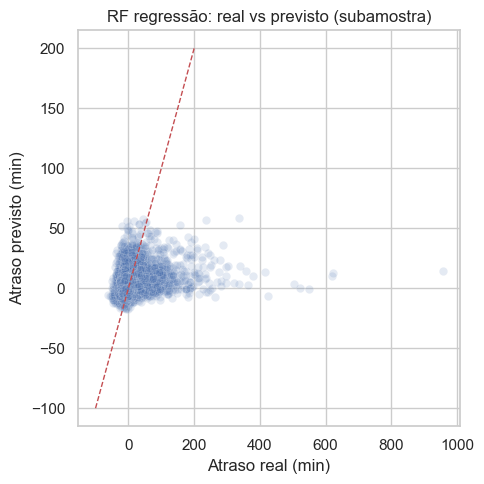

In [11]:
reg_ridge = Pipeline(
    [
        ("prep", make_column_transformer(max_categories=40)),
        ("model", Ridge(alpha=2.0, random_state=RANDOM_SEED)),
    ]
)
reg_rf = Pipeline(
    [
        ("prep", make_column_transformer(max_categories=40)),
        (
            "model",
            RandomForestRegressor(
                n_estimators=120,
                max_depth=16,
                min_samples_leaf=50,
                random_state=RANDOM_SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

reg_ridge.fit(X_train_r, y_train_r)
reg_rf.fit(X_train_r, y_train_r)


def eval_reg(name, pipe):
    pred = pipe.predict(X_test_r)
    return {
        "modelo": name,
        "MAE": mean_absolute_error(y_test_r, pred),
        "RMSE": root_mean_squared_error(y_test_r, pred),
        "R2": r2_score(y_test_r, pred),
    }


display(pd.DataFrame([eval_reg("Ridge", reg_ridge), eval_reg("Random Forest", reg_rf)]))

fig, ax = plt.subplots(figsize=(5, 5))
pred = reg_rf.predict(X_test_r)
yt = y_test_r.values if hasattr(y_test_r, "values") else np.asarray(y_test_r)
sns.scatterplot(x=yt[:8000], y=pred[:8000], alpha=0.15, ax=ax)
ax.plot([-100, 200], [-100, 200], "r--", lw=1)
ax.set_xlabel("Atraso real (min)")
ax.set_ylabel("Atraso previsto (min)")
ax.set_title("RF regressão: real vs previsto (subamostra)")
plt.tight_layout()
plt.show()

## 3. Modelagem não supervisionada

### 3.1 PCA — projeção 2D (variáveis numéricas pré-voo), cor = atrasado.

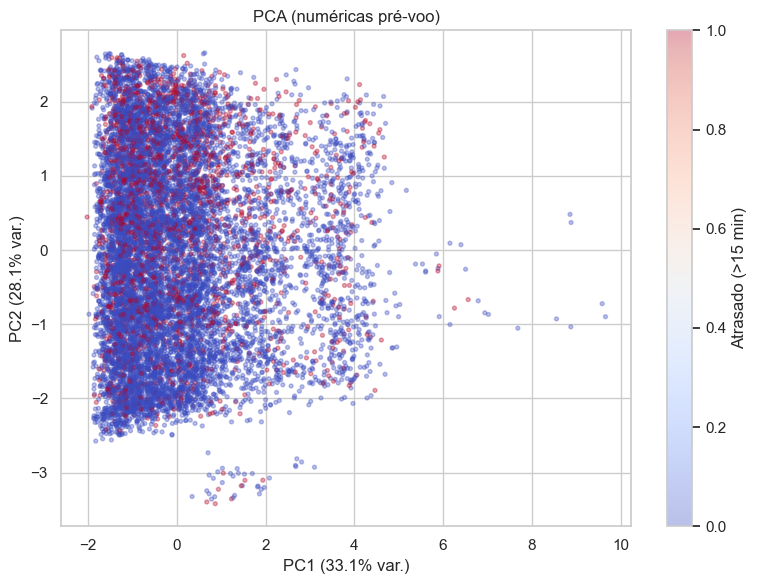

Variância explicada: [0.331  0.2814]


In [12]:
num_cols = ["MONTH", "DAY_OF_WEEK", "DEP_MIN", "ARR_MIN", "SCHEDULED_TIME", "DISTANCE"]
pca_df = model_df.dropna(subset=num_cols).sample(n=min(12000, len(model_df)), random_state=RANDOM_SEED)
Xn_s = StandardScaler().fit_transform(pca_df[num_cols].values)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(Xn_s)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    Z[:, 0],
    Z[:, 1],
    c=pca_df["DELAYED_ARRIVAL"].values,
    cmap="coolwarm",
    alpha=0.35,
    s=8,
)
plt.colorbar(scatter, label="Atrasado (>15 min)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
plt.title("PCA (numéricas pré-voo)")
plt.tight_layout()
plt.show()
print("Variância explicada:", pca.explained_variance_ratio_.round(4))

### 3.2 K-Means — perfis agregados por companhia

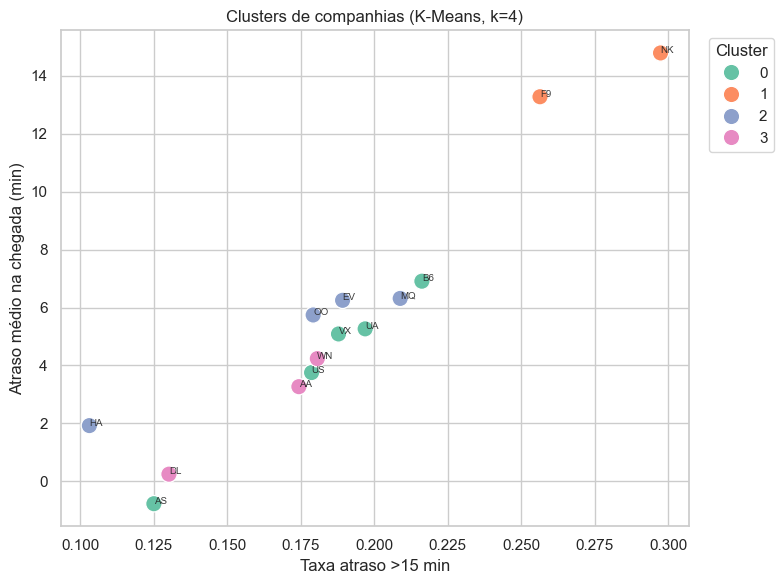

,AIRLINE,AIRLINE_NAME,delay_rate,mean_delay,n_flights,cluster
1,AS,Alaska Airlines Inc.,0.125085,-0.775850,14758,0
2,B6,JetBlue Airways,0.216246,6.910310,22812,0
10,UA,United Air Lines Inc.,0.196947,5.264310,43570,0
11,US,US Airways Inc.,0.178727,3.754474,16707,0
12,VX,Virgin America,0.187883,5.087998,5216,0
5,F9,Frontier Airlines Inc.,0.256414,13.281685,7835,1
8,NK,Spirit Air Lines,0.297425,14.794368,9979,1
4,EV,Atlantic Southeast Airlines,0.189277,6.250110,47655,2
6,HA,Hawaiian Airlines Inc.,0.103151,1.922448,6602,2
7,MQ,American Eagle Airlines Inc.,0.208867,6.315481,24068,2


In [13]:
airlines_feat = airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"})

g = model_df.groupby("AIRLINE", as_index=False).agg(
    delay_rate=("DELAYED_ARRIVAL", "mean"),
    mean_delay=("ARRIVAL_DELAY_MIN", "mean"),
    n_flights=("DELAYED_ARRIVAL", "size"),
    mean_dist=("DISTANCE", "mean"),
)
g["AIRLINE"] = g["AIRLINE"].astype(str)
feat_s = StandardScaler().fit_transform(g[["delay_rate", "mean_delay", "n_flights", "mean_dist"]].values)
km = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
g["cluster"] = km.fit_predict(feat_s)
g_lbl = g.merge(airlines_feat, left_on="AIRLINE", right_on="IATA_CODE", how="left")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=g_lbl, x="delay_rate", y="mean_delay", hue="cluster", palette="Set2", s=140)
for _, r in g_lbl.iterrows():
    plt.annotate(r["AIRLINE"], (r["delay_rate"], r["mean_delay"]), fontsize=7, alpha=0.9)
plt.xlabel("Taxa atraso >15 min")
plt.ylabel("Atraso médio na chegada (min)")
plt.title("Clusters de companhias (K-Means, k=4)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

display(
    g_lbl.sort_values("cluster")[
        ["AIRLINE", "AIRLINE_NAME", "delay_rate", "mean_delay", "n_flights", "cluster"]
    ]
)

## 4. Conclusões, limitações e próximos passos

### Principais conclusões
- A taxa de atraso varia com **mês**, **dia da semana** e **companhia**, visível no EDA e nos clusters.
- Com apenas informação pré-voo, a **classificação** costuma ter ROC-AUC moderado (o problema é intrinsecamente ruidoso); **Random Forest** tende a captar não linearidades vs regressão logística.
- A **regressão** do valor exato do atraso é mais difícil: R² baixo é esperado; MAE/RMSE em minutos permitem comparar algoritmos.
- **PCA** mostra sobreposição entre classes: os atrasos não são linearmente separáveis neste subespaço.
- **K-Means** nos perfis de companhia agrupa operadores com comportamentos semelhantes de pontualidade e magnitude de atraso (interpretável com o nome da companhia).

### Limitações
- **Amostra** parcial do ficheiro total para viabilizar RAM/tempo; estimativas têm variância de amostragem.
- **Definição de atraso** (>15 min) é arbitrária; outros limiares mudam a prevalência.
- **Regressão** usa também voos adiantados (atraso negativo); alternativa seria modelar só `max(0, delay)`.
- **Sazonalidade e eventos** (clima extremo, greves) não estão explicitamente como features.
- **Cardinalidade** de aeroportos: `max_categories` no one-hot agrupa categorias pouco frequentes.

### Melhorias
- Incluir **histórico** (atraso médio da rota/companhia em janelas anteriores) com validação temporal rigorosa.
- **Calibração** de probabilidades (Platt / isotónica) para decisões operacionais.
- Modelos de **séries tempora** ou **gradient boosting** (XGBoost/LightGBM) com *early stopping*.
- **Validação por tempo** (treino em meses anteriores, teste no mês seguinte) em vez de split aleatório.
- Enriquecer com **dados meteorológicos** ou **capacidade** de aeroporto.